## Submission 3. Phase of long theta and remote content
#### With theta from Corpus Callosum electrodes or MUA
Change%20of%20Mind%20Analysis/figure_single_cell/MakeTheta.ipynb

In [1]:
%reload_ext autoreload
%autoreload 2

In [25]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure4d import time_to_phase, remote_phase
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta, MUATheta
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.changeOfMind import color_by_rat
from spyglass.shijiegu.theta_mua import load_theta_from_calculations

In [13]:
from spyglass.shijiegu.Analysis_SGU import MUAThetaNWB, AnalysisNwbfile
import pynwb

In [14]:
analysis_nwb_file_name = (MUAThetaNWB() & {"nwb_file_name": "molly20220420_.nwb","epoch":2}).fetch1("analysis_file_name")

In [20]:
analysis_file_abs_path = (AnalysisNwbfile() & {
    "analysis_file_name":analysis_nwb_file_name}).fetch1('analysis_file_abs_path')
with pynwb.NWBHDF5IO(analysis_file_abs_path, 'r',load_namespaces=True) as io:
    nwb_file = io.read()
    df = nwb_file.scratch["theta"].to_dataframe()

[2026-01-21 15:36:46,503][WARNING]: Skipped checksum for file with hash: f76b43cc-b277-68f5-8dfe-9b44f5bce8b4, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_SEBS95C25I.nwb


In [21]:
df

,time,amplitude,phase
id,,,
0,1.650473e+09,NaN,NaN
1,1.650473e+09,NaN,NaN
2,1.650473e+09,NaN,NaN
3,1.650473e+09,NaN,NaN
4,1.650473e+09,NaN,NaN
...,...,...,...
6308687,1.650475e+09,NaN,NaN
6308688,1.650475e+09,NaN,NaN
6308689,1.650475e+09,NaN,NaN


In [116]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'molly'
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']


animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']

animal = "julio"
list_of_days_animals[animal] = ['20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']


animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']

bad_sessions = [] # these sessions have incomplete number of sorted tetrodes

In [117]:
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3'

decode_name_long = "params_both_max_segment_run_time_2_state"
decode_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
proportion = 0.1
hpd = False

for animal in ["lewis"]:
    r_phase_start_all = [] #remote theta event
    r_phase_end_all = []   #remote theta event
    l_phase_start_all = [] #local long theta event
    l_phase_end_all = []   #local long theta event
    sessions = []
    
    for d in list_of_days_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            if (animal, d, session_name) in bad_sessions:
                continue
            phase_start, phase_end = remote_phase(nwb_copy_file_name, session_name,
                                                  decode_name_long, minimum_duration_long, sd = sd, hpd = hpd, proportion = proportion,
                                                  long_flag = True, data_type = "mua")
            l_phase_start_all += phase_start
            l_phase_end_all += phase_end

            phase_start, phase_end = remote_phase(nwb_copy_file_name, session_name,
                                                  decode_name_remote, minimum_duration_remote, min_posterior = min_posterior,
                                                  proportion = proportion,
                                                  long_flag = False, data_type = "mua")
            r_phase_start_all += phase_start
            r_phase_end_all += phase_end
            
            sessions.append((animal,d, session_name))

    # save data
    data = {"l_phase_start_all": l_phase_start_all, "l_phase_end_all": l_phase_end_all,
            "r_phase_start_all": r_phase_start_all, "r_phase_end_all": r_phase_end_all,
            "sessions": sessions
           }
    data_filename = f"content_{animal}_theta_phase.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")
    

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240105_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240105_ 2         02_Rev2Session pos 1 valid ti
lewis20240105_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240105_ 4         04_Rev2Session pos 3 valid ti
lewis20240105_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240105_ 6         06_Rev2Session pos 5 valid ti
lewis20240105_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240105_ 8         08_Rev2Session pos 7 valid ti
lewis20240105_ 9         09_Rev2Sleep5  pos 8 valid ti
lewis20240105_ 10        10_Rev2Session pos 9 valid ti
 (Total: 10)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240106_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240106_ 2         02_Rev2Session pos 1 valid ti
lewis20240106_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240106_ 4         04_Rev2Session pos 3 valid

### Phase histogram

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, Akima1DInterpolator

def upsample_polar(theta, r):

    # Convert to Cartesian
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    # 2. Interpolate in Cartesian space
    # Ensure the curve closes smoothly by appending the start point to the end
    x = np.append(x, x[0])
    y = np.append(y, y[0])
    t = np.linspace(0, 1, len(x)) # Parameter t
    t_smooth = np.linspace(0, 1, 300) # Finer parameter t for smoothness
    
    cs_x = Akima1DInterpolator(t, x)
    cs_y = Akima1DInterpolator(t, y)
    
    x_smooth = cs_x(t_smooth)
    y_smooth = cs_y(t_smooth)
    
    # 3. Convert back to polar
    r_smooth = np.sqrt(x_smooth**2 + y_smooth**2)
    theta_smooth = np.arctan2(y_smooth, x_smooth)
    return theta_smooth, r_smooth
    
    # # 4. Plotting
    # fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    # ax.scatter(theta, r, color='red', label='Original Data')
    # ax.plot(theta_smooth, r_smooth, label='Smoothed Curve', color='blue')
    # ax.set_title("Smoothed Polar Plot using Cubic Spline")
    # ax.legend()
    # plt.show()

In [119]:
def plot_polar_hist(angles, ax, animal, num_bins = 30):
    # 3. Calculate the histogram
    num_bins = 16
    hist_counts, bin_edges = np.histogram(angles, bins=num_bins, range=(0, 2 * np.pi), weights = np.ones(len(angles))/len(angles))

    # 4. Plot the histogram using ax.bar
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bar_width = np.diff(bin_edges)

    color = color_by_rat[animal.lower()]
    bin_centers, hist_counts = upsample_polar(bin_centers, hist_counts)
    ax.plot(bin_centers, hist_counts, color=color_by_rat[animal], linewidth = 3, alpha = 0.5)
    #ax.bar(bin_centers, hist_counts, width=bar_width, color=color, alpha = 0.5, edgecolor='none')
    #ax.fill(bin_centers, hist_counts, facecolor=color_by_rat[animal], alpha=0.3)

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/content_lewis_theta_phase.pkl


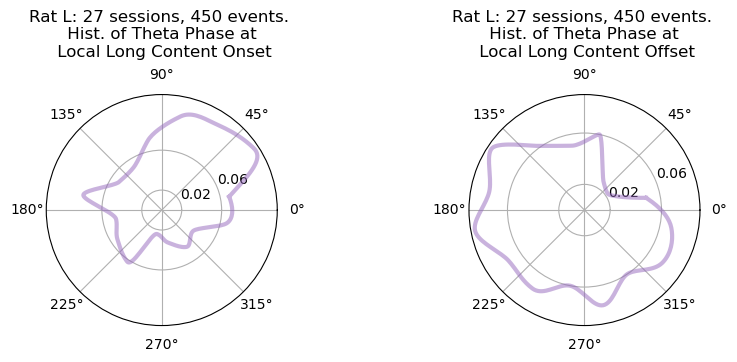

In [120]:
animal = 'lewis'

data_filename = f"content_{animal}_theta_phase.pkl"
output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    data = pickle.load(file)
print(f"Data loaded from {output_path}")

sessions = data["sessions"]

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,3))

#### 1. Onset
ax = axes[0]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["l_phase_start_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Local Long Content Onset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06])

#### 2. Offset
ax = axes[1]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["l_phase_end_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

# 5. Customize the plot (optional)
ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Local Long Content Offset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06])

# You can further customize labels, tick marks, etc.

# 6. Display the plot
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/longlocal_content_phase_{animal}_muatheta.pdf',dpi=300,bbox_inches='tight')

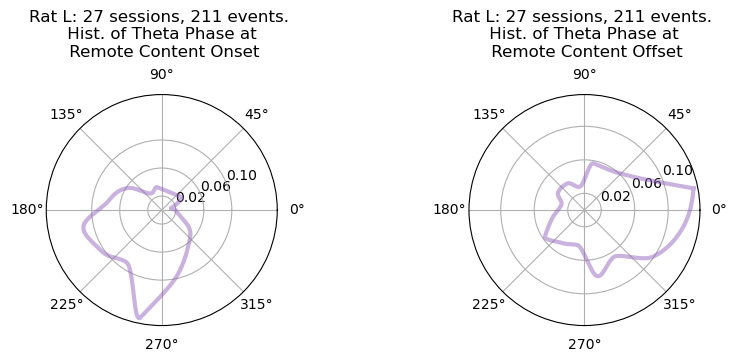

In [121]:
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,3))
sessions = data["sessions"]

#### 1. Onset
ax = axes[0]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["r_phase_start_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Remote Content Onset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06, 0.1])

#### 2. Offset
ax = axes[1]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["r_phase_end_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

# 5. Customize the plot (optional)
ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Remote Content Offset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06, 0.1])

# You can further customize labels, tick marks, etc.

# 6. Display the plot
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/remote_content_phase_{animal}_muatheta.pdf',dpi=300,bbox_inches='tight')


### End here